# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



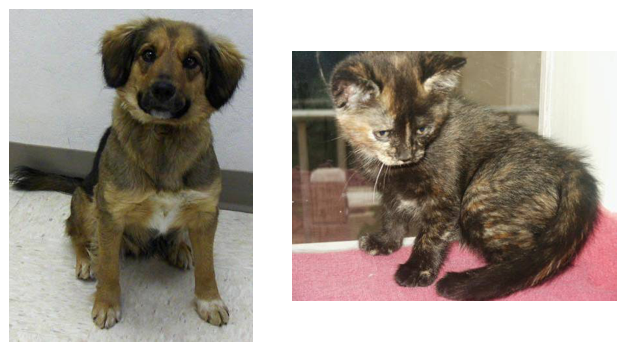

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [7]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt

import torch
from torchvision import datasets, transforms

import helper


La façon la plus simple de charger des images est d’utiliser `datasets.ImageFolder` de la bibliothèque **torchvision** ([documentation](http://pytorch.org/docs/master/torchvision/datasets.html#imagefolder)).  
En général, vous utiliserez `ImageFolder` comme ceci :

```python
dataset = datasets.ImageFolder('path/to/data', transform=transform)
````

où `'path/to/data'` est le chemin d’accès au répertoire contenant les données, et `transform` est une **séquence d’opérations de prétraitement** définies à l’aide du module [`transforms`](http://pytorch.org/docs/master/torchvision/transforms.html) de `torchvision`.

`ImageFolder` s’attend à une structure de répertoires comme celle-ci :

```
root/dog/xxx.png
root/dog/xxy.png
root/dog/xxz.png

root/cat/123.png
root/cat/nsdf3.png
root/cat/asd932_.png
```

Chaque classe (ici `cat` et `dog`) possède son **propre dossier** contenant les images correspondantes.
Les images sont alors automatiquement **étiquetées** d’après le nom du dossier.
Ainsi, l’image `123.png` sera chargée avec l’étiquette `cat`.

Vous pouvez télécharger le jeu de données déjà structuré de cette manière [ici](https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip).
Il est déjà séparé en **jeu d’entraînement** et **jeu de test**.

---

### 🔄 Transformations

Lors du chargement des données avec `ImageFolder`, il faut définir des **transformations (transforms)**.
Par exemple, les images ont des tailles différentes, mais le modèle nécessite qu’elles aient toutes la même taille pour l’entraînement.
On peut donc :

* les **redimensionner** avec `transforms.Resize()`, ou
* les **rogner** avec `transforms.CenterCrop()` ou `transforms.RandomResizedCrop()`.

Il faut également **convertir les images en tenseurs PyTorch** à l’aide de `transforms.ToTensor()`.

En général, ces étapes sont combinées en un pipeline à l’aide de `transforms.Compose()`, qui exécute une liste de transformations dans l’ordre.
Par exemple, pour redimensionner, recadrer, puis convertir en tenseur :

```python
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])
```

Il existe de nombreuses autres transformations possibles — consultez la [documentation](http://pytorch.org/docs/master/torchvision/transforms.html) pour plus de détails.

---

### 📦 Data Loaders

Une fois le `ImageFolder` chargé, il faut le passer à un [`DataLoader`](http://pytorch.org/docs/master/data.html#torch.utils.data.DataLoader).
Le **DataLoader** prend un dataset (par exemple celui renvoyé par `ImageFolder`) et retourne des **lots (batches)** d’images et leurs **étiquettes** correspondantes.
Vous pouvez régler plusieurs paramètres, comme :

* la **taille des lots (`batch_size`)**,
* et le **mélange des données (`shuffle`)** à chaque époque.

Exemple :

```python
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
```

L’objet `dataloader` est un **générateur**.
Pour extraire des données, on peut soit boucler dessus, soit le convertir en itérateur et appeler `next()` :

```python
# Boucle pour récupérer un batch à chaque itération
for images, labels in dataloader:
    pass

# Obtenir un seul batch
images, labels = next(iter(dataloader))
```

---

> **Exercice :**
> Chargez les images depuis le dossier `Cat_Dog_data/train`,
> définissez quelques transformations,
> puis construisez le **DataLoader**.



In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
%cd /content/drive/MyDrive/DIT/deepL/cnn_cat_dog_image_classification

/content/drive/MyDrive/DIT/deepL/cnn_cat_dog_image_classification


In [10]:
%ls

best_scratch_adam.pt  cnn_catsdogs_complet.ipynb  training_utils.py
Cat_Dog_data/         my_helper.py


In [11]:
# extract Cat_Dog_data.zip
#!unzip Cat_Dog_data.zip

In [12]:
data_dir = 'Cat_Dog_data/train'

#transform = # TODO: compose transforms here
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])

#dataset = # TODO: create the ImageFolder
dataset = datasets.ImageFolder(data_dir, transform=transform)

#dataloader = # TODO: use the ImageFolder dataset to create the DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()

    image = image.numpy().transpose((1, 2, 0))

    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

<Axes: >

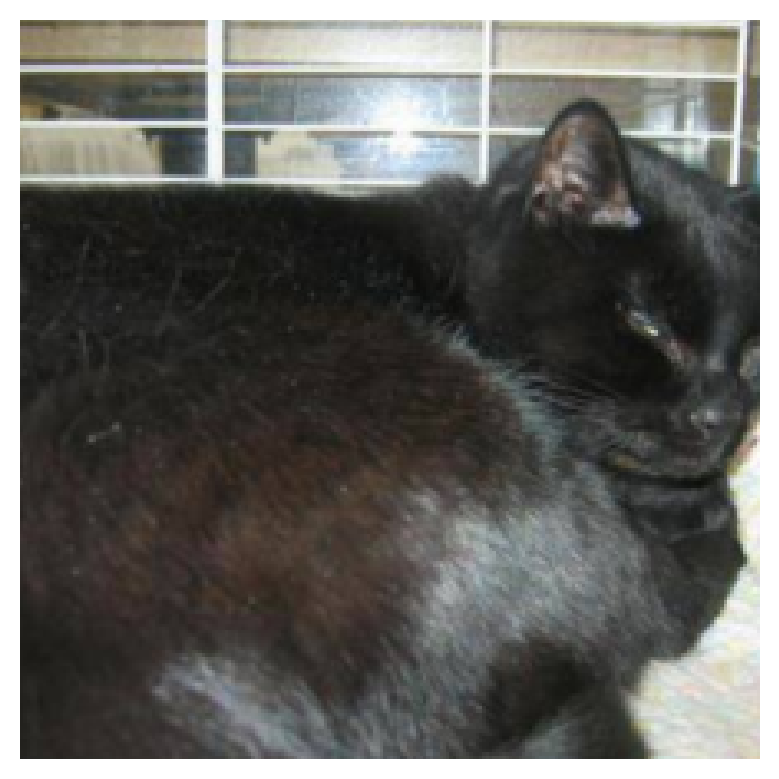

In [14]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0], normalize=False)

Si vous avez correctement chargé les données, vous devriez obtenir un affichage similaire à celui-ci (votre image sera différente) :




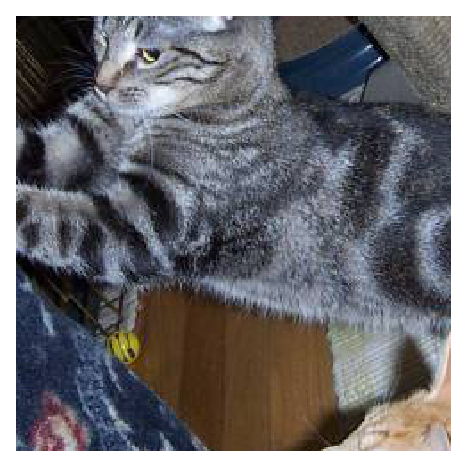


## Augmentation de Données

Une stratégie courante pour entraîner des réseaux de neurones consiste à introduire une **certaine forme d’aléatoire dans les données d’entrée**.  
Par exemple, on peut faire tourner, refléter, redimensionner et/ou rogner aléatoirement les images pendant l’entraînement.  
Cela aide le réseau à **mieux généraliser**, car il voit les mêmes images sous différentes formes : positions, tailles, orientations, etc.

Pour appliquer une rotation, un recadrage et un redimensionnement aléatoires, puis retourner les images horizontalement, on peut définir les transformations ainsi :

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])
````

Il est également recommandé de **normaliser les images** à l’aide de `transforms.Normalize`.
Cette transformation prend en entrée :

* une liste de **moyennes** (`mean`)
* et une liste d’**écarts-types** (`std`)

Chaque canal de couleur est alors normalisé selon la formule :

```
input[channel] = (input[channel] - mean[channel]) / std[channel]
```

Soustraire la moyenne recentre les données autour de zéro,
et diviser par l’écart-type comprime les valeurs entre **-1 et 1**.
Cette normalisation aide à maintenir les **poids du réseau proches de zéro**,
rendant ainsi la **rétropropagation plus stable**.
Sans normalisation, le réseau risque souvent d’échouer à apprendre correctement.

Vous pouvez consulter la **liste complète des transformations disponibles** [ici](http://pytorch.org/docs/0.3.0/torchvision/transforms.html).

Lors des phases de **validation** ou de **test**, on utilise généralement des images **non altérées** (hormis la normalisation).
Ainsi, pour les données de validation ou de test, on se contente en général de **redimensionner** et **recadrer** les images.

---

> **Exercice :**
> Définissez ci-dessous les **transformations** pour les données d’entraînement et de test.
> Ne mettez pas encore la normalisation.

```



In [15]:
data_dir = 'Cat_Dog_data'

# Stats ImageNet : utilisées par tous les modèles pré-entraînés torchvision
# (dont ResNet50 plus bas). Les garder aussi pour le CNN from scratch ne
# coûte rien et stabilise un peu l'entraînement (entrées centrées/réduites).
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


# Pass transforms in here, then run the next cell to see how the transforms look
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

trainloader = torch.utils.data.DataLoader(train_data, batch_size=32)
testloader = torch.utils.data.DataLoader(test_data, batch_size=32)

In [16]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

In [17]:
images, labels = next(data_iter)
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])

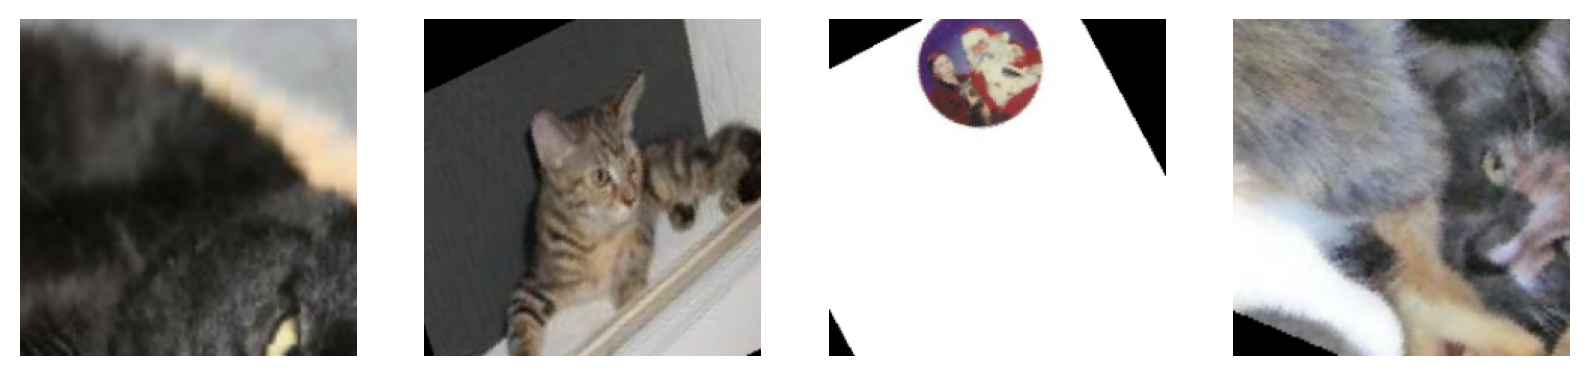

In [18]:


images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax, normalize=True)  # normalize=True car les tensors sont Normalize()'d

Vos images transformées devraient ressembler à quelque chose comme ceci.




<center>Training examples:</center>


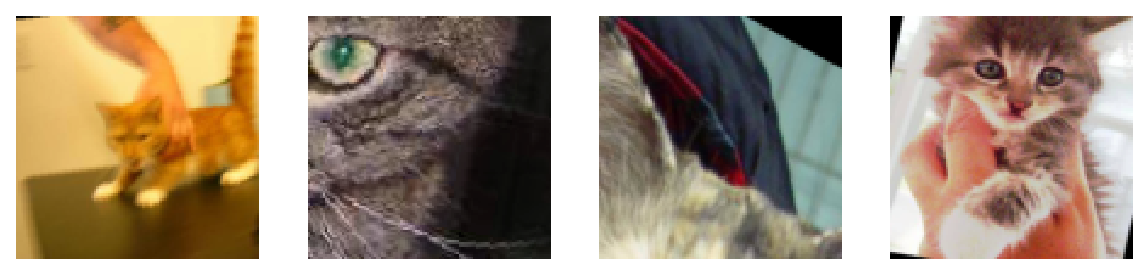

<center>Testing examples:</center>

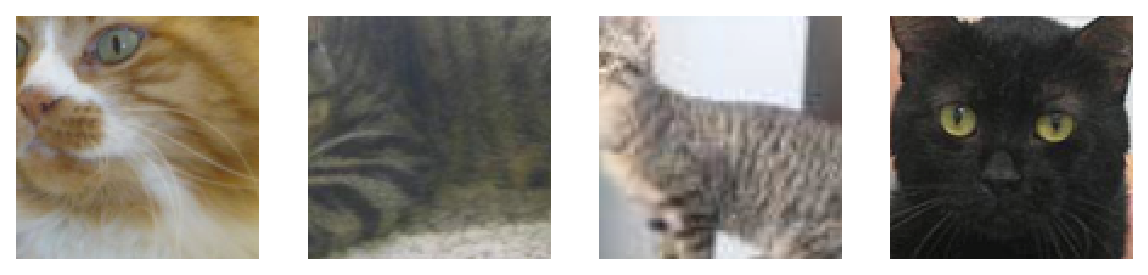


À ce stade, vous devriez être en mesure de charger les données pour l’entraînement et le test.  
Vous pouvez maintenant essayer de construire un réseau capable de **classer les chats et les chiens**.



---
# DEVOIR — CNN "from scratch" vs Transfert Learning (Cats vs Dogs)

**Suite directe de ce qui précède** — on repart de `train_data` / `test_data` / `train_transforms` / `test_transforms` déjà définis ci-dessus (cellule avec `data_dir = 'Cat_Dog_data'`), sans retoucher au chargement ni à la normalisation des données.

Comparaison d'un CNN entraîné **from scratch** et d'un modèle en **transfert d'apprentissage** (ResNet50 pré-entraîné), chacun testé avec **2 optimiseurs** (Adam et SGD), soit **4 expériences** au total :

1. From scratch — Adam
2. From scratch — SGD
3. Transfer learning — Adam
4. Transfer learning — SGD

Métriques suivies à chaque époque : **loss**, **accuracy**, **precision**, **recall** (train et validation). Le meilleur modèle de chaque expérience est sauvegardé puis rechargé pour l'évaluation finale sur le jeu de test.

> **Remarque :** `training_utils.py` doit se trouver dans ce même dossier Drive. Il ne redéfinit pas le chargement des données (déjà fait ci-dessus) — il apporte uniquement : le split train/valid, les boucles d'entraînement/évaluation avec métriques (accuracy, precision, recall), la sauvegarde du meilleur modèle, le test final et le lr_finder.

In [19]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.2 MB/s eta 0:00:00


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models

from training_utils import (
    make_data_loaders,
    optimize,
    test_model,
    plot_confusion_matrix,
    lr_finder,
    seed,
    device,
)

print("Device utilisé :", device)
print("Seed fixé à :", seed)

Device utilisé : cuda
Seed fixé à : 42


/content/drive/MyDrive/DIT/deepL/cnn_cat_dog_image_classification/training_utils.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


---
## Data loaders (train / valid / test)

On repart de `train_data` et `test_data` tels que construits ci-dessus. On réserve simplement 15% de `train_data` pour la validation.

In [21]:
data_loaders = make_data_loaders(train_data, test_data, batch_size=32, valid_size=0.15)

classes = train_data.classes  # déduit automatiquement par ImageFolder
n_classes = len(classes)

print(classes)
print({k: len(v.dataset) for k, v in data_loaders.items()})

['cat', 'dog']
{'train': 22500, 'valid': 22500, 'test': 2500}


---
# Expérience 1 & 2 — CNN "from scratch"

Architecture à **4 blocs conv** (Conv2d → BatchNorm2d → ReLU → MaxPool2d) suivis d'un **Global Average Pooling** puis d'une tête dense légère, avec Dropout.

- **BatchNorm** après chaque conv, avant l'activation : stabilise la distribution des activations dès le début de l'entraînement, alors que les poids sont initialisés aléatoirement (pas de pré-entraînement ici).
- **Global Average Pooling** plutôt qu'un flatten complet : évite une couche fc1 à ~25M de paramètres (128*28*28*256 dans la version à 3 blocs), ce qui accélère nettement l'entraînement et réduit l'overfitting, tout en permettant un 4e bloc conv (plus de capacité représentationnelle) sans exploser le nombre de paramètres.
- **Dropout** avant la couche dense finale (0.4) : limite l'overfitting sur un jeu de données modeste, sans perturber l'extraction de features des couches conv.


In [22]:
# define the CNN architecture
class Net(nn.Module):


    def __init__(self, n_classes=2):
        super(Net, self).__init__()

        # Bloc 1 : 224x224x3 -> 112x112x32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Bloc 2 : 112x112x32 -> 56x56x64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Bloc 3 : 56x56x64 -> 28x28x128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Bloc 4 : 28x28x128 -> 14x14x256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap = nn.AdaptiveAvgPool2d(1)  # 14x14x256 -> 1x1x256, quelle que soit la taille d'entrée

        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # -> 112x112x32
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # -> 56x56x64
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # -> 28x28x128
        x = self.pool(F.relu(self.bn4(self.conv4(x))))   # -> 14x14x256

        x = self.gap(x)
        x = x.view(x.size(0), -1)  # -> (batch, 256)

        x = self.dropout(x)
        x = self.fc(x)  # logits bruts, CrossEntropyLoss applique le softmax

        return x

In [23]:
model_scratch = Net(n_classes=n_classes)
print(model_scratch)
model_scratch.to(device)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

In [24]:
# Combien de paramètres ?
sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)

389890

In [25]:
loss = nn.CrossEntropyLoss()

### Recherche du learning rate (lr_finder)

On utilise le lr_finder pour identifier une bonne zone de learning rate avant l'entraînement complet.

In [26]:
losses = lr_finder(1e-5, 0.5, 100, loss, model_scratch, data_loaders)

Learning rate finder:  17%|███▎                | 99/598 [07:46<39:12,  4.71s/it]


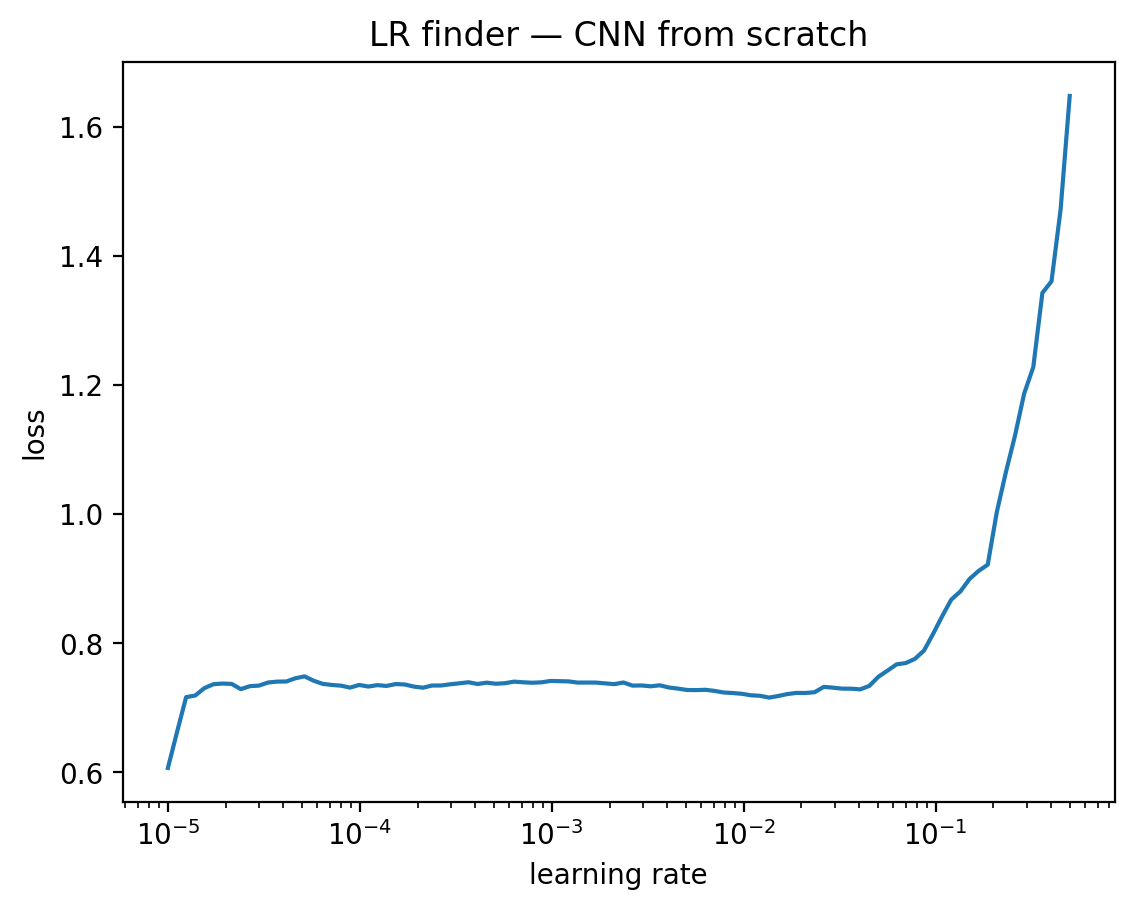

In [27]:
_ = plt.plot(list(losses.keys()), list(losses.values()))
_ = plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("loss")
plt.title("LR finder — CNN from scratch")
plt.show()

## Expérience 1 — From scratch + Adam

In [28]:
print(torch.cuda.is_available(), device)

True cuda


In [29]:
n_epochs = 20
lr = 1e-3  # à ajuster selon la courbe du lr_finder ci-dessus

model_scratch_adam = Net(n_classes=n_classes)
optimizer = optim.Adam(model_scratch_adam.parameters(), lr=lr)

history_scratch_adam = optimize(
    data_loaders, model_scratch_adam, optimizer, loss,
    n_epochs, "best_scratch_adam.pt", n_classes=n_classes
)

Validating: 100%|█████████████████████████████| 106/106 [05:06<00:00,  2.89s/it]


Epoch 01 | train loss 0.6716 acc 0.5894 | valid loss 0.6393 acc 0.6363 prec 0.6403 rec 0.6363


Validating: 100%|█████████████████████████████| 106/106 [00:21<00:00,  4.92it/s]

Epoch 02 | train loss 0.6254 acc 0.6527 | valid loss 0.6209 acc 0.6649 prec 0.6757 rec 0.6649



Validating: 100%|█████████████████████████████| 106/106 [00:21<00:00,  4.82it/s]

...

Epoch 18 | train loss 0.4555 acc 0.7880 | valid loss 0.4538 acc 0.7893 prec 0.7985 rec 0.7893



Validating: 100%|█████████████████████████████| 106/106 [00:21<00:00,  4.92it/s]

Epoch 19 | train loss 0.4437 acc 0.7926 | valid loss 0.5616 acc 0.7345 prec 0.7490 rec 0.7345



Validating: 100%|█████████████████████████████| 106/106 [00:19<00:00,  5.38it/s]

Epoch 20 | train loss 0.4354 acc 0.7991 | valid loss 0.4059 acc 0.8136 prec 0.8136 rec 0.8136


In [30]:
model_scratch_adam.load_state_dict(torch.load("best_scratch_adam.pt"))

test_loss_scratch_adam, preds_scratch_adam, actuals_scratch_adam = test_model(
    data_loaders["test"], model_scratch_adam, loss
)

Testing: 100%|██████████████████████████████████| 79/79 [07:59<00:00,  6.08s/it]

Test Loss: 0.386452
Test Accuracy: 83.64% (2091/2500)


,cat,dog
cat,1031,219
dog,190,1060


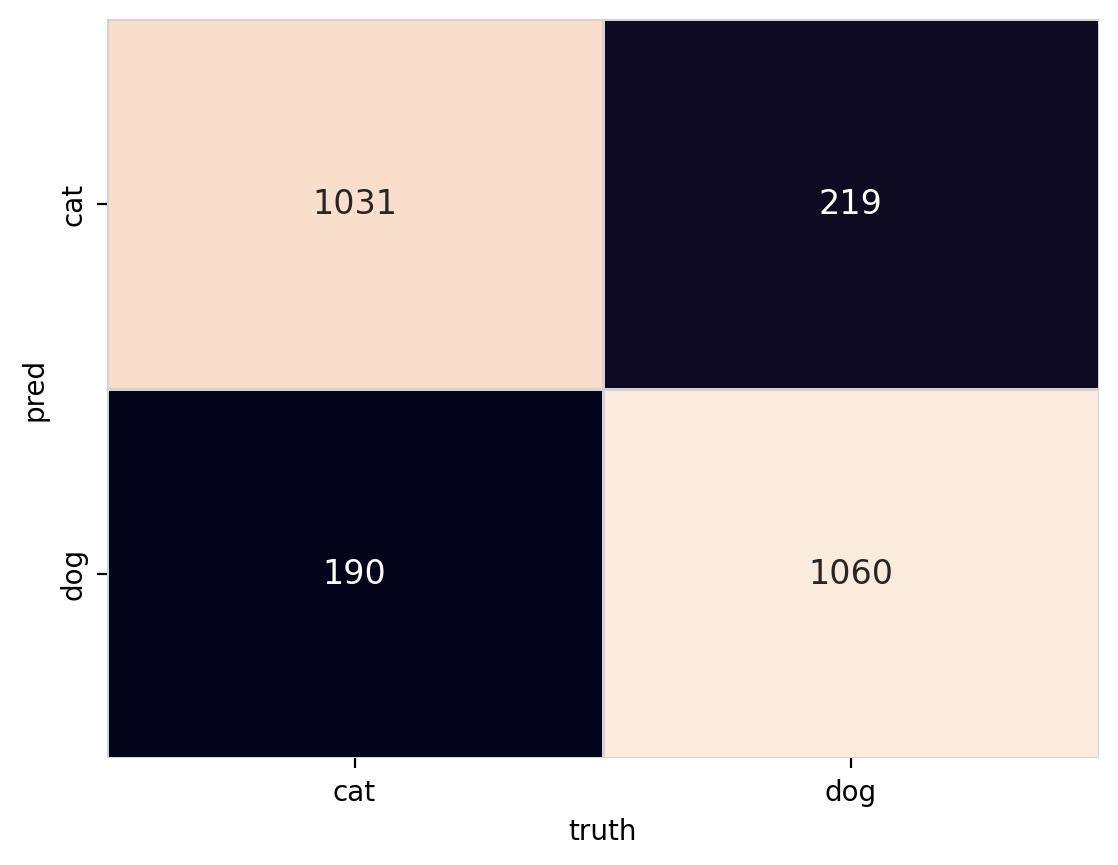

In [31]:
plot_confusion_matrix(preds_scratch_adam, actuals_scratch_adam, classes)

## Expérience 2 — From scratch + SGD

In [32]:
n_epochs = 20
lr = 1e-2  # SGD nécessite généralement un lr plus élevé qu'Adam

model_scratch_sgd = Net(n_classes=n_classes)
optimizer = optim.SGD(model_scratch_sgd.parameters(), lr=lr, momentum=0.9)

history_scratch_sgd = optimize(
    data_loaders, model_scratch_sgd, optimizer, loss,
    n_epochs, "best_scratch_sgd.pt", n_classes=n_classes
)

Validating: 100%|█████████████████████████████| 106/106 [00:21<00:00,  4.97it/s]

Epoch 01 | train loss 0.7142 acc 0.5670 | valid loss 0.6627 acc 0.6024 prec 0.6716 rec 0.6024



Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.22it/s]

Epoch 02 | train loss 0.6815 acc 0.6035 | valid loss 0.6288 acc 0.6673 prec 0.6680 rec 0.6673



Validating: 100%|█████████████████████████████| 106/106 [00:19<00:00,  5.53it/s]


...

Epoch 18 | train loss 0.5334 acc 0.7346 | valid loss 0.5528 acc 0.7224 prec 0.7313 rec 0.7224



Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.20it/s]

Epoch 19 | train loss 0.5243 acc 0.7373 | valid loss 0.4982 acc 0.7615 prec 0.7622 rec 0.7615



Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.05it/s]

Epoch 20 | train loss 0.5141 acc 0.7478 | valid loss 0.5227 acc 0.7391 prec 0.7735 rec 0.7391


In [33]:
model_scratch_sgd.load_state_dict(torch.load("best_scratch_sgd.pt"))

test_loss_scratch_sgd, preds_scratch_sgd, actuals_scratch_sgd = test_model(
    data_loaders["test"], model_scratch_sgd, loss
)

Testing: 100%|██████████████████████████████████| 79/79 [00:12<00:00,  6.22it/s]

Test Loss: 0.483642
Test Accuracy: 77.44% (1936/2500)


,cat,dog
cat,908,342
dog,222,1028


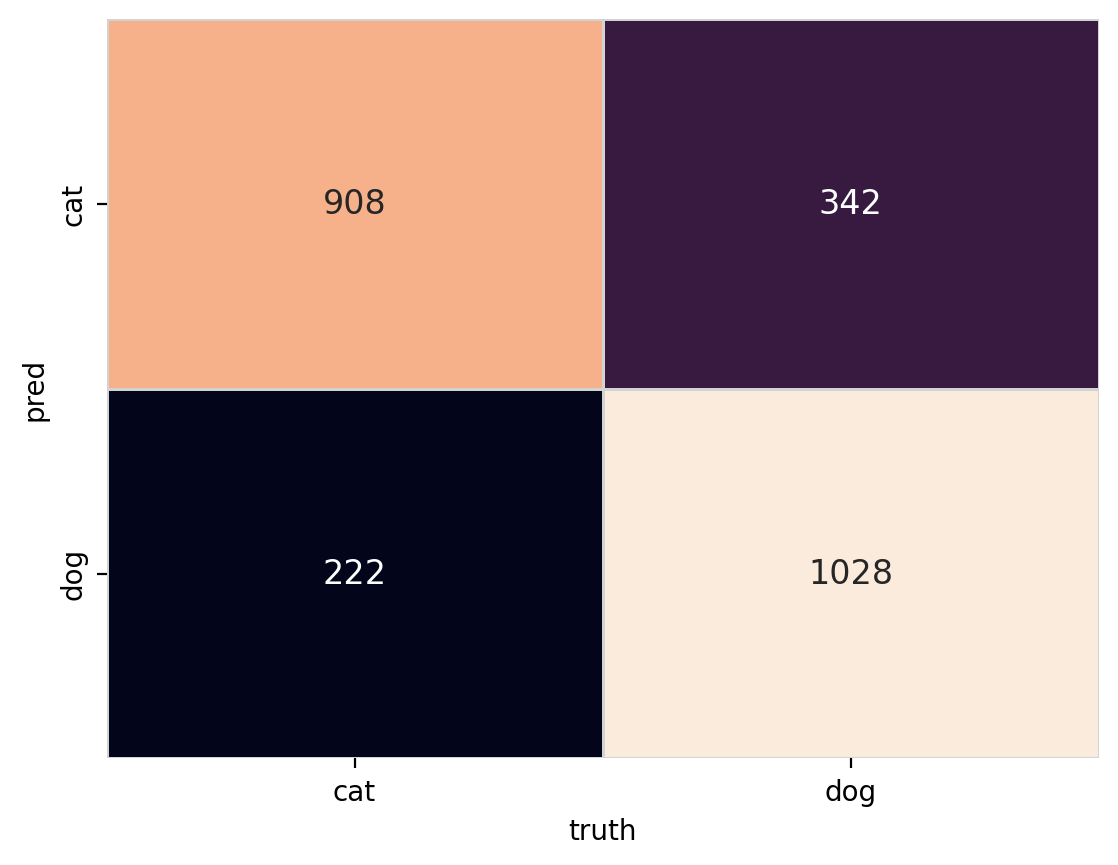

In [34]:
plot_confusion_matrix(preds_scratch_sgd, actuals_scratch_sgd, classes)

### Comparaison Adam vs SGD — From scratch

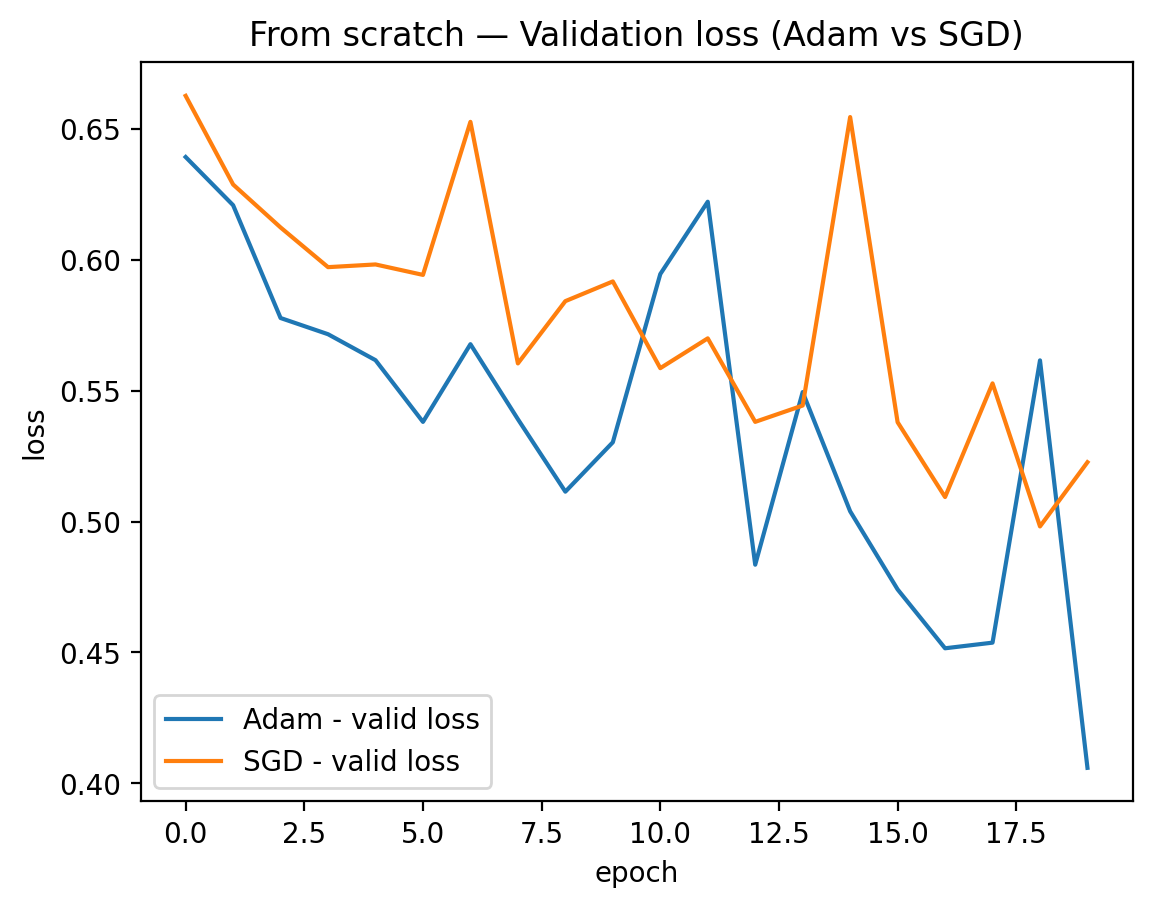

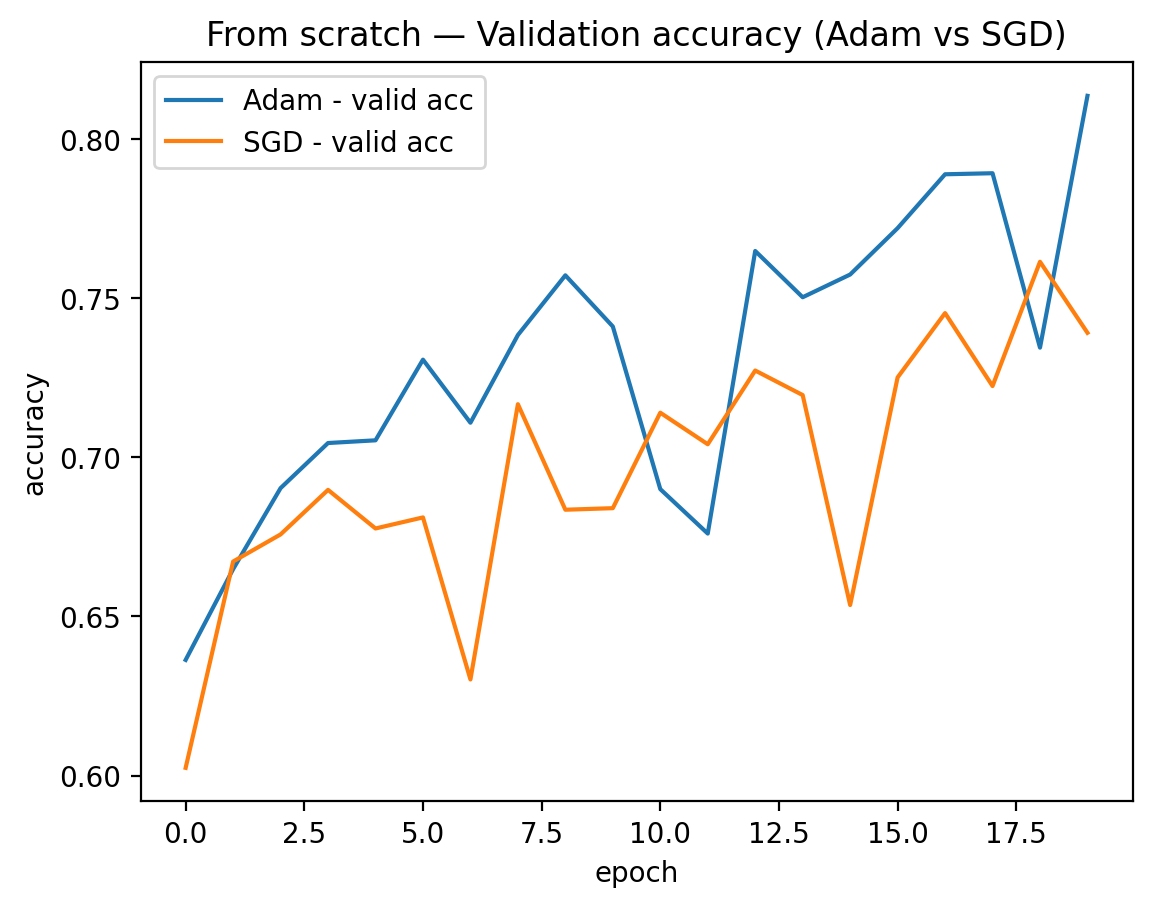

Adam -> test loss 0.3865
SGD  -> test loss 0.4836


In [35]:
plt.figure()
plt.plot(history_scratch_adam["valid_loss"], label="Adam - valid loss")
plt.plot(history_scratch_sgd["valid_loss"], label="SGD - valid loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("From scratch — Validation loss (Adam vs SGD)")
plt.show()

plt.figure()
plt.plot(history_scratch_adam["valid_acc"], label="Adam - valid acc")
plt.plot(history_scratch_sgd["valid_acc"], label="SGD - valid acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("From scratch — Validation accuracy (Adam vs SGD)")
plt.show()

print(f"Adam -> test loss {test_loss_scratch_adam:.4f}")
print(f"SGD  -> test loss {test_loss_scratch_sgd:.4f}")

---
# Expérience 3 & 4 — Transfer Learning (ResNet50)

On charge un ResNet50 pré-entraîné sur ImageNet, on remplace sa tête de classification, on gèle le backbone pour entraîner uniquement la tête, puis on dégèle pour faire du fine-tuning à faible learning rate.

`train_data`/`test_data` sont maintenant normalisés avec les stats ImageNet (`transforms.Normalize`, voir la cellule de transforms plus haut) — important pour que le backbone pré-entraîné reçoive des entrées dans la distribution sur laquelle il a été entraîné.

In [36]:
def build_transfer_model(n_classes):
    model = torchvision.models.resnet50(pretrained=True)

    n_inputs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(n_inputs, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, n_classes)
    )

    # Geler le backbone, dégeler uniquement la tête
    frozen_parameters = []
    for p in model.parameters():
        if p.requires_grad:
            p.requires_grad = False
            frozen_parameters.append(p)

    for p in model.fc.parameters():
        p.requires_grad = True

    print(f"{len(frozen_parameters)} groupes de paramètres gelés")
    return model, frozen_parameters

## Expérience 3 — Transfer learning + Adam

**Phase 1 :** on entraîne uniquement la tête (backbone gelé).
**Phase 2 :** on dégèle tout le réseau et on fait du fine-tuning à un learning rate 100x plus faible.

In [37]:
model_tl_adam, frozen_params_adam = build_transfer_model(n_classes)
model_tl_adam.to(device)

loss_tl = nn.CrossEntropyLoss()

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


163 groupes de paramètres gelés


In [38]:
# Phase 1 : tête seule
n_epochs = 5
lr = 0.005

optimizer = optim.Adam(model_tl_adam.parameters(), lr=lr)

history_tl_adam_head = optimize(
    data_loaders, model_tl_adam, optimizer, loss_tl,
    n_epochs, "tl_adam_head.pt", n_classes=n_classes
)

Validating: 100%|█████████████████████████████| 106/106 [00:22<00:00,  4.74it/s]


Epoch 01 | train loss 0.3048 acc 0.8841 | valid loss 0.1530 acc 0.9354 prec 0.9354 rec 0.9354


Validating: 100%|█████████████████████████████| 106/106 [00:21<00:00,  4.98it/s]


Epoch 02 | train loss 0.2379 acc 0.8970 | valid loss 0.1258 acc 0.9497 prec 0.9498 rec 0.9497


Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.11it/s]

Epoch 03 | train loss 0.1972 acc 0.9127 | valid loss 0.1307 acc 0.9424 prec 0.9425 rec 0.9424



Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.05it/s]

Epoch 04 | train loss 0.2112 acc 0.9040 | valid loss 0.1783 acc 0.9317 prec 0.9357 rec 0.9317



Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.12it/s]

Epoch 05 | train loss 0.2039 acc 0.9106 | valid loss 0.1383 acc 0.9410 prec 0.9419 rec 0.9410


In [39]:
# Phase 2 : fine-tuning (backbone dégelé, lr très réduit)
for p in frozen_params_adam:
    p.requires_grad = True

n_epochs = 10
lr = 0.005 / 100

optimizer = optim.Adam(model_tl_adam.parameters(), lr=lr)

history_tl_adam_finetune = optimize(
    data_loaders, model_tl_adam, optimizer, loss_tl,
    n_epochs, "tl_adam_finetune.pt", n_classes=n_classes
)

Validating: 100%|█████████████████████████████| 106/106 [00:22<00:00,  4.70it/s]


Epoch 01 | train loss 0.1670 acc 0.9303 | valid loss 0.1139 acc 0.9629 prec 0.9630 rec 0.9629


Validating: 100%|█████████████████████████████| 106/106 [00:21<00:00,  4.99it/s]


Epoch 02 | train loss 0.1285 acc 0.9479 | valid loss 0.1126 acc 0.9556 prec 0.9556 rec 0.9556


Validating: 100%|█████████████████████████████| 106/106 [00:20<00:00,  5.18it/s]


...

Epoch 08 | train loss 0.0857 acc 0.9652 | valid loss 0.0990 acc 0.9602 prec 0.9605 rec 0.9602



Validating: 100%|█████████████████████████████| 106/106 [00:25<00:00,  4.20it/s]

Epoch 09 | train loss 0.0859 acc 0.9659 | valid loss 0.0885 acc 0.9620 prec 0.9622 rec 0.9620



Validating: 100%|█████████████████████████████| 106/106 [00:25<00:00,  4.22it/s]


Epoch 10 | train loss 0.0896 acc 0.9644 | valid loss 0.0787 acc 0.9644 prec 0.9645 rec 0.9644


In [40]:
model_tl_adam.load_state_dict(torch.load("tl_adam_finetune.pt"))

test_loss_tl_adam, preds_tl_adam, actuals_tl_adam = test_model(
    data_loaders["test"], model_tl_adam, loss_tl
)

Testing: 100%|██████████████████████████████████| 79/79 [00:17<00:00,  4.54it/s]

Test Loss: 0.027595
Test Accuracy: 98.76% (2469/2500)


,cat,dog
cat,1242,8
dog,23,1227


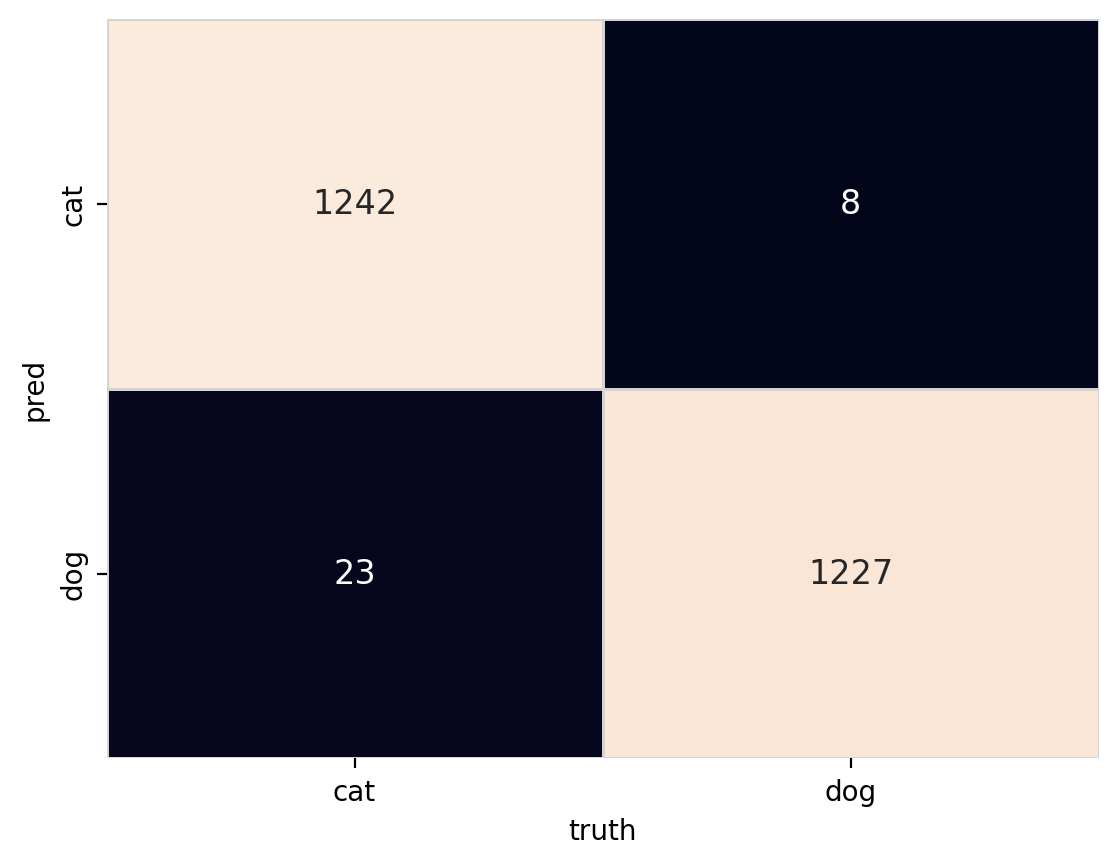

In [41]:
plot_confusion_matrix(preds_tl_adam, actuals_tl_adam, classes)

## Expérience 4 — Transfer learning + SGD

In [42]:
model_tl_sgd, frozen_params_sgd = build_transfer_model(n_classes)
model_tl_sgd.to(device)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


163 groupes de paramètres gelés


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [43]:
# Phase 1 : tête seule
n_epochs = 5
lr = 0.01

optimizer = optim.SGD(model_tl_sgd.parameters(), lr=lr, momentum=0.9)

history_tl_sgd_head = optimize(
    data_loaders, model_tl_sgd, optimizer, loss_tl,
    n_epochs, "tl_sgd_head.pt", n_classes=n_classes
)

Validating: 100%|█████████████████████████████| 106/106 [00:24<00:00,  4.39it/s]


Epoch 01 | train loss 0.2323 acc 0.8960 | valid loss 0.1454 acc 0.9355 prec 0.9355 rec 0.9355


Validating: 100%|█████████████████████████████| 106/106 [00:25<00:00,  4.16it/s]

Epoch 02 | train loss 0.1922 acc 0.9167 | valid loss 0.2473 acc 0.8837 prec 0.9043 rec 0.8837



Validating: 100%|█████████████████████████████| 106/106 [00:25<00:00,  4.17it/s]


Epoch 03 | train loss 0.1830 acc 0.9204 | valid loss 0.1368 acc 0.9380 prec 0.9383 rec 0.9380


Validating: 100%|█████████████████████████████| 106/106 [00:23<00:00,  4.56it/s]


Epoch 04 | train loss 0.1768 acc 0.9225 | valid loss 0.1269 acc 0.9441 prec 0.9455 rec 0.9441


Validating: 100%|█████████████████████████████| 106/106 [00:25<00:00,  4.22it/s]

Epoch 05 | train loss 0.1685 acc 0.9259 | valid loss 0.1532 acc 0.9333 prec 0.9342 rec 0.9333


In [44]:
# Phase 2 : fine-tuning (backbone dégelé, lr très réduit)
for p in frozen_params_sgd:
    p.requires_grad = True

n_epochs = 10
lr = 0.01 / 100

optimizer = optim.SGD(model_tl_sgd.parameters(), lr=lr, momentum=0.9)

history_tl_sgd_finetune = optimize(
    data_loaders, model_tl_sgd, optimizer, loss_tl,
    n_epochs, "tl_sgd_finetune.pt", n_classes=n_classes
)

Validating: 100%|█████████████████████████████| 106/106 [00:24<00:00,  4.32it/s]


Epoch 01 | train loss 0.1502 acc 0.9355 | valid loss 0.1054 acc 0.9555 prec 0.9556 rec 0.9555


Validating: 100%|█████████████████████████████| 106/106 [00:23<00:00,  4.50it/s]


Epoch 02 | train loss 0.1278 acc 0.9455 | valid loss 0.1006 acc 0.9603 prec 0.9603 rec 0.9603


Validating: 100%|█████████████████████████████| 106/106 [00:24<00:00,  4.28it/s]


...

Epoch 08 | train loss 0.0925 acc 0.9631 | valid loss 0.0761 acc 0.9706 prec 0.9710 rec 0.9706



Validating: 100%|█████████████████████████████| 106/106 [00:27<00:00,  3.90it/s]


Epoch 09 | train loss 0.0890 acc 0.9629 | valid loss 0.0709 acc 0.9709 prec 0.9713 rec 0.9709


Validating: 100%|█████████████████████████████| 106/106 [00:27<00:00,  3.87it/s]


Epoch 10 | train loss 0.0899 acc 0.9632 | valid loss 0.0667 acc 0.9718 prec 0.9720 rec 0.9718


In [45]:
model_tl_sgd.load_state_dict(torch.load("tl_sgd_finetune.pt"))

test_loss_tl_sgd, preds_tl_sgd, actuals_tl_sgd = test_model(
    data_loaders["test"], model_tl_sgd, loss_tl
)

Testing: 100%|██████████████████████████████████| 79/79 [00:19<00:00,  4.14it/s]

Test Loss: 0.026492
Test Accuracy: 99.00% (2475/2500)


,cat,dog
cat,1236,14
dog,11,1239


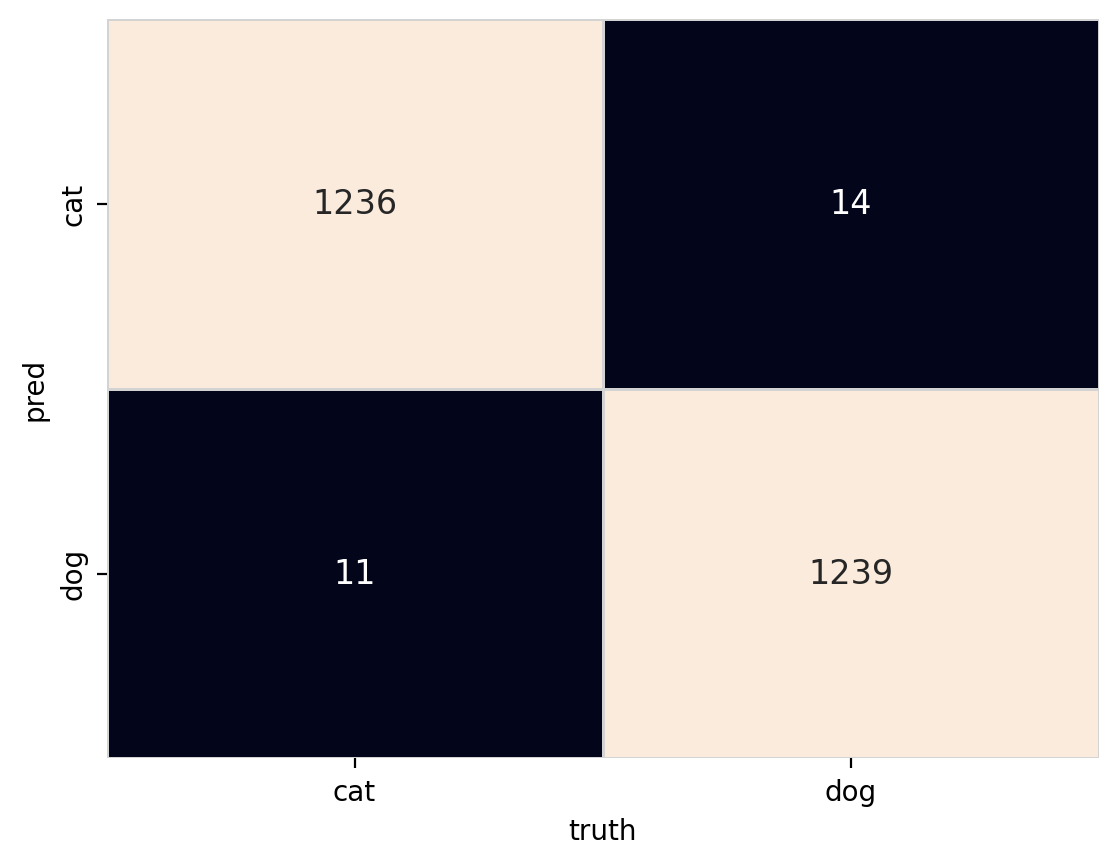

In [46]:
plot_confusion_matrix(preds_tl_sgd, actuals_tl_sgd, classes)

### Comparaison Adam vs SGD — Transfer learning (fine-tuning)

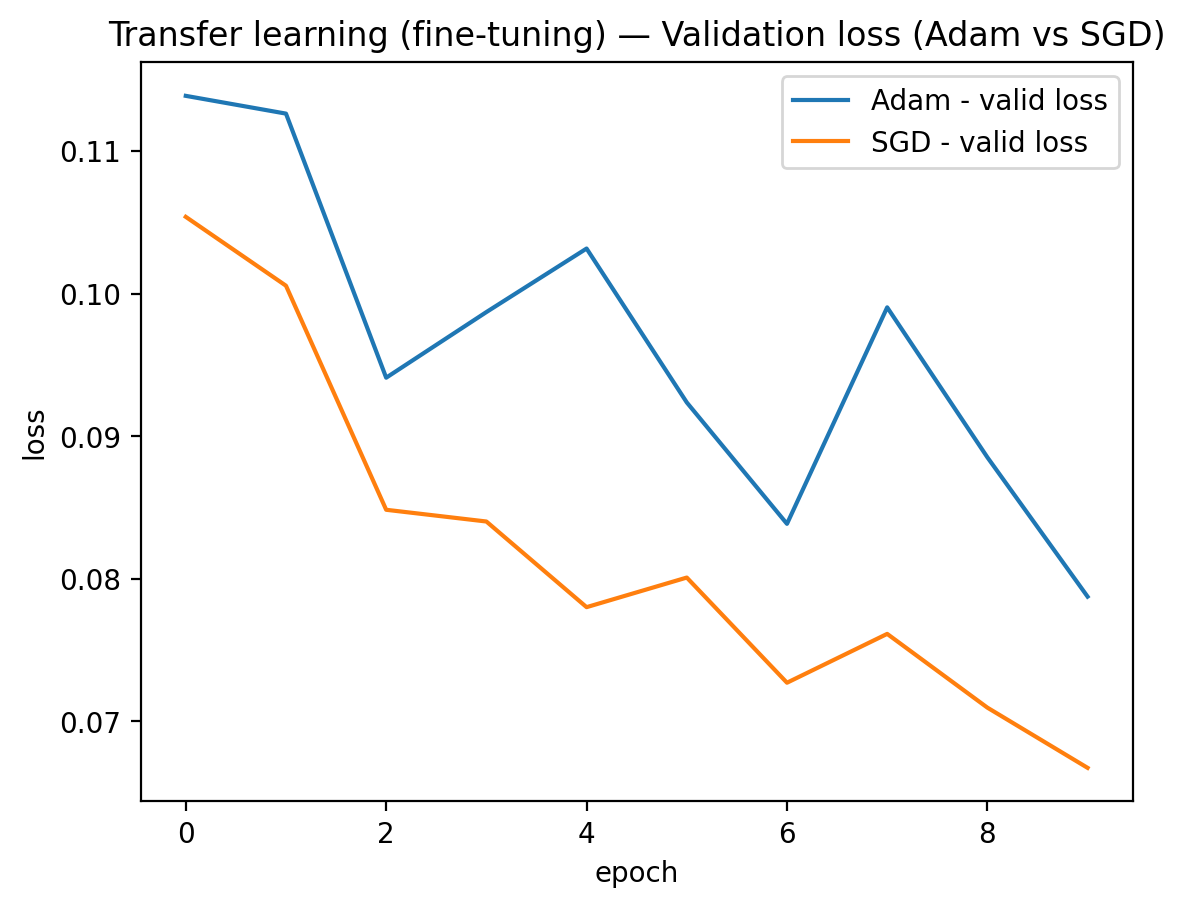

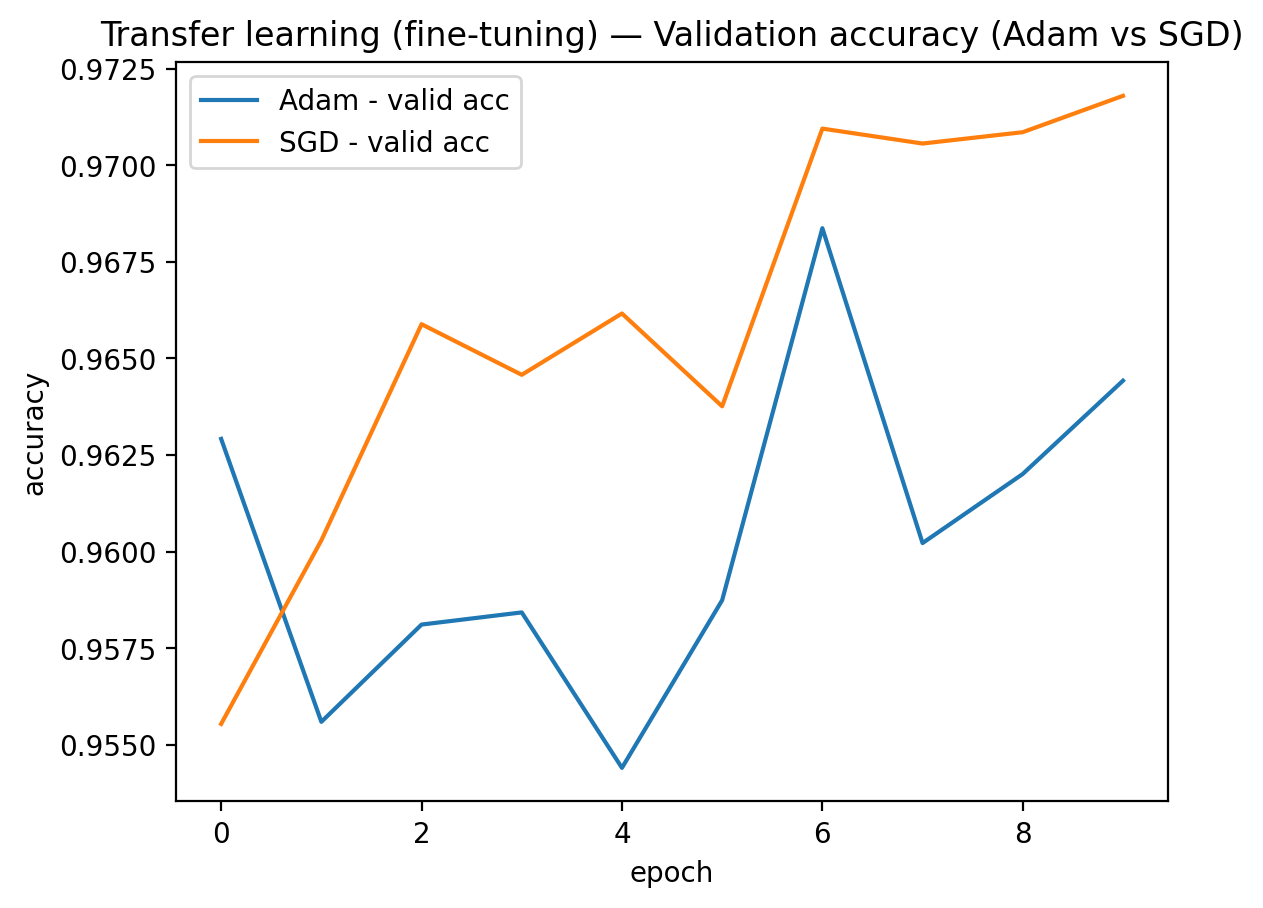

Adam -> test loss 0.0276
SGD  -> test loss 0.0265


In [47]:
plt.figure()
plt.plot(history_tl_adam_finetune["valid_loss"], label="Adam - valid loss")
plt.plot(history_tl_sgd_finetune["valid_loss"], label="SGD - valid loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Transfer learning (fine-tuning) — Validation loss (Adam vs SGD)")
plt.show()

plt.figure()
plt.plot(history_tl_adam_finetune["valid_acc"], label="Adam - valid acc")
plt.plot(history_tl_sgd_finetune["valid_acc"], label="SGD - valid acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.title("Transfer learning (fine-tuning) — Validation accuracy (Adam vs SGD)")
plt.show()

print(f"Adam -> test loss {test_loss_tl_adam:.4f}")
print(f"SGD  -> test loss {test_loss_tl_sgd:.4f}")

---
# Comparaison globale — From scratch vs Transfer learning

Comparaison des 4 expériences sur la validation accuracy.

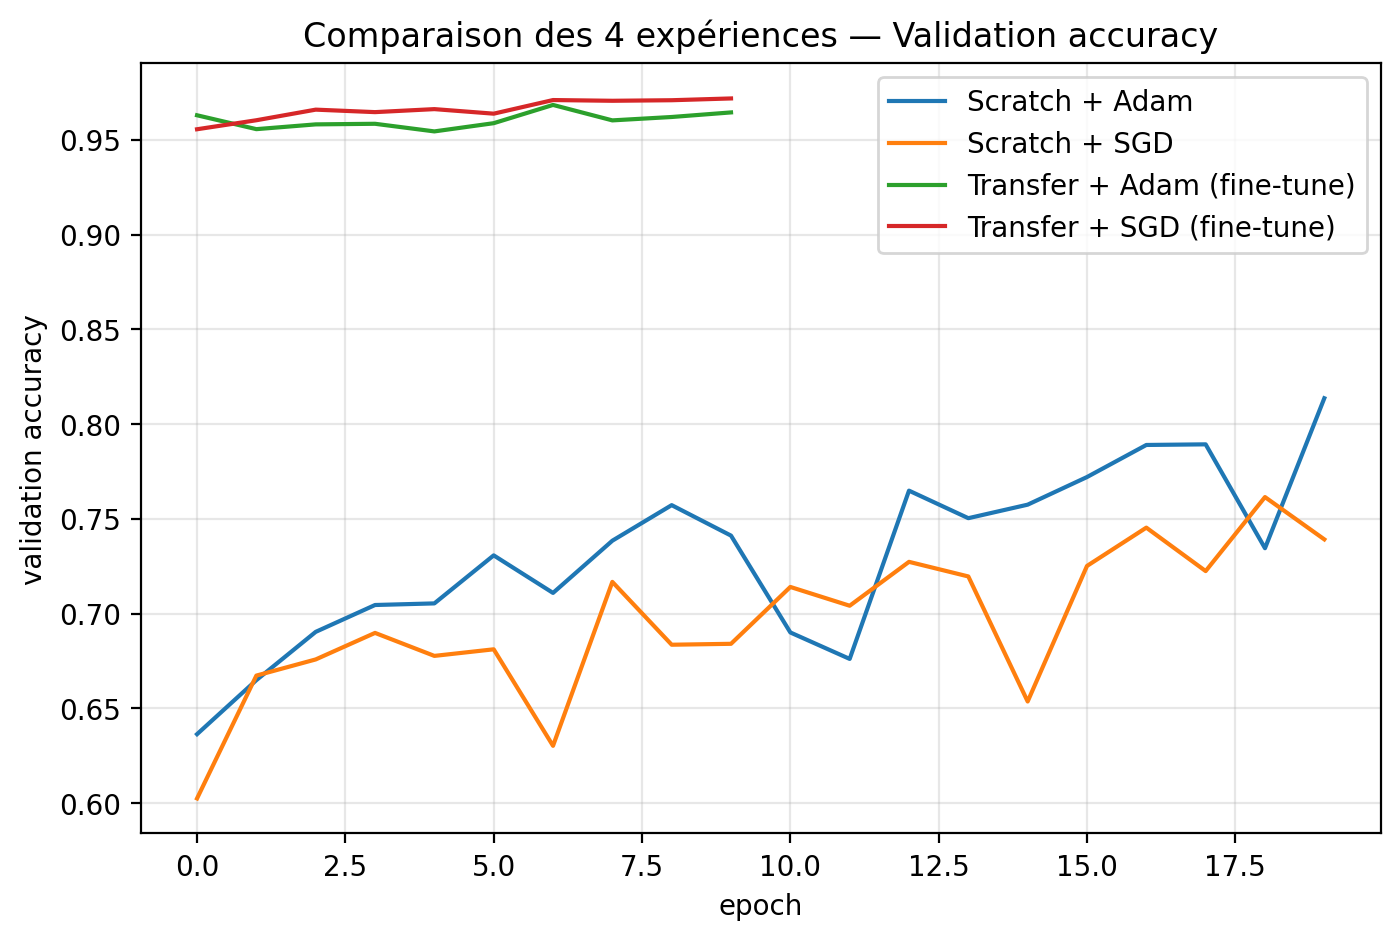

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(history_scratch_adam["valid_acc"], label="Scratch + Adam")
plt.plot(history_scratch_sgd["valid_acc"], label="Scratch + SGD")
plt.plot(history_tl_adam_finetune["valid_acc"], label="Transfer + Adam (fine-tune)")
plt.plot(history_tl_sgd_finetune["valid_acc"], label="Transfer + SGD (fine-tune)")
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.legend()
plt.title("Comparaison des 4 expériences — Validation accuracy")
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
print("=== Résultats finaux (test set) ===")
print(f"1. From scratch + Adam       -> loss {test_loss_scratch_adam:.4f}")
print(f"2. From scratch + SGD        -> loss {test_loss_scratch_sgd:.4f}")
print(f"3. Transfer learning + Adam  -> loss {test_loss_tl_adam:.4f}")
print(f"4. Transfer learning + SGD   -> loss {test_loss_tl_sgd:.4f}")

=== Résultats finaux (test set) ===
1. From scratch + Adam       -> loss 0.3865
2. From scratch + SGD        -> loss 0.4836
3. Transfer learning + Adam  -> loss 0.0276
4. Transfer learning + SGD   -> loss 0.0265


### Question : Quelles sont les faiblesses de chaque approche et comment pourraient-elles être améliorées ?

**Réponse** :

